In [19]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [20]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
print(df.shape)
print(df.columns)
print(df.info())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


In [22]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


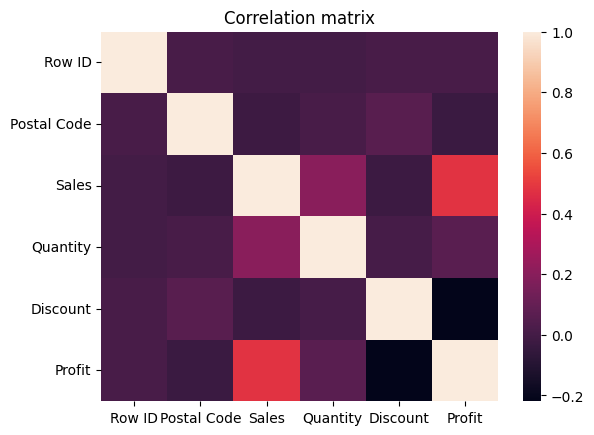

In [23]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation matrix")
plt.show()

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month

In [25]:
df = df.drop([
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Product Name',
    'City',
    'State',
    'Country',
    'Ship Date',
    'Order Date',
    'Postal Code',
    'Profit'
], axis=1)

In [26]:
# target
X = df.drop('Sales', axis=1)
y = df['Sales']

In [27]:
categorical_features = [
    'Ship Mode',
    'Segment',
    'Region',
    'Category',
    'Sub-Category'
]

numeric_features = [
    'Quantity',
    'Discount',
    'order_year',
    'order_month'
]

In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
pred_lr = lr_pipeline.predict(X_test)

In [31]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
pred_rf = rf_pipeline.predict(X_test)

In [33]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
pred_xgb = xgb_pipeline.predict(X_test)

In [34]:
#сравнение моделей
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_xgb))
    ],
    'R2': [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb)
    ]
})

print(results)

               Model         MAE        RMSE        R2
0  Linear Regression  226.362425  693.342018  0.186179
1      Random Forest  215.225520  687.163334  0.200619
2            XGBoost  196.565317  672.482683  0.234411


In [35]:
joblib.dump(xgb_pipeline, 'model.pkl')

['model.pkl']

In [36]:
!pip install streamlit pyngrok

In [49]:
%%writefile requirements.txt
streamlit==1.57.0
pandas==2.2.2
scikit-learn==1.6.1
xgboost==3.2.0
joblib==1.5.3
matplotlib==3.10.0
seaborn==0.13.2
numpy==1.26.4

Writing requirements.txt


In [44]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

model = joblib.load('model.pkl')

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month

st.title("Superstore Sales Prediction")

ship_mode = st.selectbox("Ship Mode", df['Ship Mode'].unique())
segment = st.selectbox("Segment", df['Segment'].unique())
region = st.selectbox("Region", df['Region'].unique())
category = st.selectbox("Category", df['Category'].unique())
sub_category = st.selectbox("Sub-Category", df['Sub-Category'].unique())

quantity = st.slider("Quantity", 1, 14, 1)
discount = st.slider("Discount", 0.0, 1.0, 0.0)

year = st.selectbox("Year", sorted(df['order_year'].unique()))
month = st.slider("Month", 1, 12, 1)

if st.button("Predict Sales"):
    input_df = pd.DataFrame([{
        'Ship Mode': ship_mode,
        'Segment': segment,
        'Region': region,
        'Category': category,
        'Sub-Category': sub_category,
        'Quantity': quantity,
        'Discount': discount,
        'order_year': year,
        'order_month': month
    }])

    pred = model.predict(input_df)
    st.success(f"Predicted Sales: ${pred[0]:.2f}")

st.subheader("Sales Distribution")
fig, ax = plt.subplots()
ax.hist(df['Sales'], bins=30)
st.pyplot(fig)

Writing app.py


In [48]:
import streamlit
import pandas
import sklearn
import xgboost
import joblib
import matplotlib
import seaborn

print("matplotlib:", matplotlib.__version__)
print("streamlit:", streamlit.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

matplotlib: 3.10.0
streamlit: 1.57.0
pandas: 2.2.2
sklearn: 1.6.1
xgboost: 3.2.0
joblib: 1.5.3
